In [28]:
# example of bayesian optimization for a 1d function from scratch
from math import sin
from math import pi
from numpy import arange
from numpy import vstack
from numpy import argmax
from numpy import asarray
from numpy.random import normal
from numpy.random import random
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from warnings import catch_warnings
from warnings import simplefilter
from matplotlib import pyplot

In [29]:
# objective function
def objective(x, noise=0.1):
  noise = normal(loc=0, scale=noise)
  return (x**2 * sin(5 * pi * x)**6.0) + noise

In [30]:
# surrogate or approximation for the objective function
def surrogate(model, X):
 # catch any warning generated when making a prediction
 with catch_warnings():
  # ignore generated warnings
  simplefilter ("ignore")
  return model.predict(X, return_std=True)

In [31]:
# probability of improvement acquisition function
def acquisition(X, Xsamples, model):
 # calculate the best surrogate score found so far
 yhat, _ = surrogate(model, X)
 best = max(yhat)
 # calculate mean and stdev via surrogate function
 mu, std = surrogate(model, Xsamples)
 #mu = mu[:, 0]
 # calculate the probability of improvement
 probs = norm.cdf((mu - best) / (std+1E-9))
 return probs

In [32]:
# optimize the acquisition function
def opt_acquisition(X, y, model):
 # random search, generate random samples
 Xsamples = random(100)
 Xsamples = Xsamples.reshape(len(Xsamples), 1)
 # calculate the acquisition function for each sample
 scores = acquisition(X, Xsamples, model)
 # locate the index of the largest scores
 ix = argmax(scores)
 return Xsamples[ix, 0]

In [33]:
# plot real observations vs surrogate function
def plot(X, y, model):
 # scatter plot of inputs and real objective function
 pyplot.scatter(X, y)
 # line plot of surrogate function across domain
 Xsamples = asarray(arange(0, 1, 0.001))
 Xsamples = Xsamples.reshape(len(Xsamples), 1)
 ysamples, _ = surrogate(model, Xsamples)
 pyplot.plot(Xsamples, ysamples)
 # show the plot
 pyplot.show()

In [34]:
# sample the domain sparsely with noise
X =random(100)
y =asarray([objective(x) for x in X])

In [35]:
# reshape into rows and cols
X =X.reshape(len(X), 1)
y =y.reshape(len(y), 1)

In [36]:
# define the model
model = GaussianProcessRegressor()
# fit the model
model.fit(X, y)

GaussianProcessRegressor()

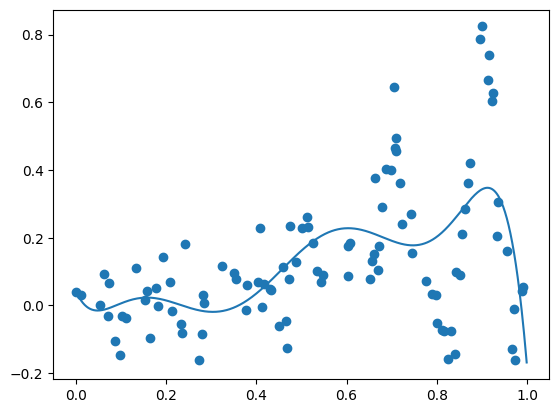

In [37]:
# plot before hand
plot(X, y, model)

In [38]:
# perform the optimization process
for i in range(100):
 # select the next point to sample
 x =opt_acquisition(X, y, model)
 # sample the point
 actual = objective(x)
 # summarize the finding
 est, _ = surrogate(model, [[x]])
 print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
 # add the data to the dataset
 X =vstack((X, [[x]]))
 y =vstack((y, [[actual ]]) )
 # update the model
 model.fit(X, y)

/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: D

>x=0.025, f()=-0.004096, actual=-0.016
>x=0.912, f()=0.347422, actual=0.731
>x=0.164, f()=0.023883, actual=0.042
>x=0.471, f()=0.127248, actual=0.223
>x=0.914, f()=0.374181, actual=0.761
>x=0.429, f()=0.075671, actual=0.133
>x=0.914, f()=0.399167, actual=0.803
>x=0.735, f()=0.165592, actual=0.218
>x=0.914, f()=0.423119, actual=0.702
>x=0.714, f()=0.169567, actual=0.460
>x=0.458, f()=0.118976, actual=-0.061
>x=0.820, f()=0.262531, actual=-0.013
>x=0.676, f()=0.200056, actual=0.120
>x=0.487, f()=0.154769, actual=0.096
>x=0.032, f()=-0.016717, actual=0.075
>x=0.153, f()=0.030184, actual=0.096
>x=0.935, f()=0.409054, actual=0.275
>x=0.915, f()=0.424390, actual=0.704
>x=0.257, f()=-0.014410, actual=-0.082
>x=0.223, f()=0.002327, actual=0.113
>x=0.137, f()=0.034831, actual=0.194
>x=0.571, f()=0.231385, actual=-0.105
>x=0.913, f()=0.438129, actual=0.575
>x=0.840, f()=0.304979, actual=0.390
>x=0.408, f()=0.035223, actual=-0.019
>x=0.406, f()=0.031492, actual=0.149
>x=0.309, f()=-0.023028, actu

/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: D

>x=0.488, f()=0.142605, actual=0.173
>x=0.723, f()=0.156780, actual=0.448
>x=0.732, f()=0.167458, actual=0.236
>x=0.203, f()=0.033698, actual=0.041
>x=0.019, f()=0.007634, actual=-0.046
>x=0.912, f()=0.451517, actual=0.704
>x=0.001, f()=0.042274, actual=-0.106
>x=0.160, f()=0.047487, actual=-0.010
>x=0.736, f()=0.168355, actual=0.302
>x=0.483, f()=0.137249, actual=0.060
>x=0.483, f()=0.135156, actual=0.100
>x=0.011, f()=-0.016611, actual=-0.073
>x=0.911, f()=0.460823, actual=0.885
>x=0.268, f()=-0.007416, actual=-0.050
>x=0.347, f()=-0.017317, actual=0.156
>x=0.010, f()=-0.022192, actual=0.009
>x=0.105, f()=0.020235, actual=0.088
>x=0.652, f()=0.196087, actual=0.218
>x=0.558, f()=0.207844, actual=0.089
>x=0.463, f()=0.109550, actual=0.097
>x=0.103, f()=0.022438, actual=0.036
>x=0.020, f()=-0.028367, actual=0.129
>x=0.329, f()=-0.015709, actual=-0.013
>x=0.688, f()=0.176124, actual=0.287
>x=0.289, f()=-0.012491, actual=0.035
>x=0.911, f()=0.476109, actual=0.898
>x=0.685, f()=0.178225, a

/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: D

>x=0.039, f()=-0.023965, actual=-0.045
>x=0.912, f()=0.512963, actual=0.775
>x=0.126, f()=0.042627, actual=-0.008
>x=0.433, f()=0.072704, actual=-0.040
>x=0.011, f()=-0.005267, actual=0.069
>x=0.913, f()=0.521750, actual=0.779
>x=0.340, f()=-0.018589, actual=0.005
>x=0.066, f()=-0.010993, actual=-0.071
>x=0.419, f()=0.052071, actual=0.112
>x=0.750, f()=0.155030, actual=-0.002
>x=0.770, f()=0.171119, actual=-0.005
>x=0.541, f()=0.198678, actual=0.003
>x=0.978, f()=0.111129, actual=0.018
>x=0.912, f()=0.529791, actual=0.799
>x=0.837, f()=0.338700, actual=0.063
>x=0.427, f()=0.061649, actual=-0.091
>x=0.461, f()=0.104839, actual=0.123
>x=0.337, f()=-0.022581, actual=0.052
>x=0.976, f()=0.136209, actual=0.099
>x=0.678, f()=0.148947, actual=0.330
>x=0.554, f()=0.203534, actual=0.034
>x=0.867, f()=0.437193, actual=0.496
>x=0.918, f()=0.532891, actual=0.749
>x=0.454, f()=0.095199, actual=-0.074
>x=0.493, f()=0.143163, actual=0.377
>x=0.672, f()=0.155750, actual=0.345
>x=0.112, f()=0.028827, a

/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))
/tmp/ipython-input-38-3407090693.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))


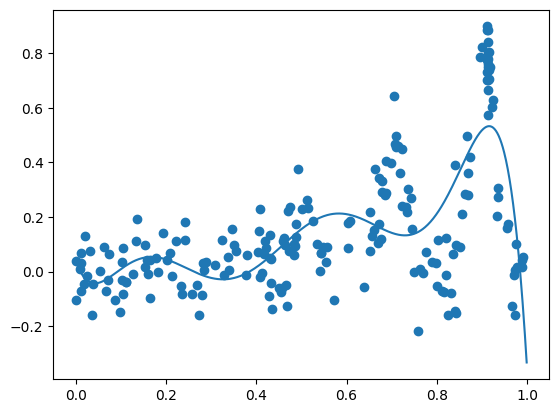

Best Result: x=0.911, y=0.898


/tmp/ipython-input-39-2062943715.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Best Result: x=%.3f, y=%.3f' % (X[ix], y[ix]))


In [39]:
# plot all samples and the final surrogate function
plot(X, y, model)
# best result
ix = argmax(y)
print('Best Result: x=%.3f, y=%.3f' % (X[ix], y[ix]))